In [ ]:
# Check Python version
import sys
print(sys.version)


3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
!pip install kaggle tensorflow numpy pandas matplotlib seaborn scikit-learn nltk


In [ ]:
!mkdir -p data/full_dataset

!wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv
!wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv
!wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_3.csv


--2026-01-26 13:17:59--  https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.163.207, 142.251.16.207, 192.178.218.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.163.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14174600 (14M) [application/octet-stream]
Saving to: ‘data/full_dataset/goemotions_1.csv’

goemotions_1.csv    100%[===================>]  13.52M  --.-KB/s    in 0.1s    

2026-01-26 13:17:59 (102 MB/s) - ‘data/full_dataset/goemotions_1.csv’ saved [14174600/14174600]

--2026-01-26 13:17:59--  https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.163.207, 142.251.16.207, 192.178.218.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.163.207|:443... connected.
HTTP request sent, awaiting 

In [ ]:
!ls data/full_dataset


goemotions_1.csv  goemotions_2.csv  goemotions_3.csv


In [ ]:
import pandas as pd

df1 = pd.read_csv("data/full_dataset/goemotions_1.csv")
df2 = pd.read_csv("data/full_dataset/goemotions_2.csv")
df3 = pd.read_csv("data/full_dataset/goemotions_3.csv")

go_df = pd.concat([df1, df2, df3], ignore_index=True)

print(go_df.shape)
go_df.head()


(211225, 37)


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
go_df.columns


Index(['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id',
       'created_utc', 'rater_id', 'example_very_unclear', 'admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='object')

In [ ]:
selected_emotions = ["anger", "fear", "sadness", "joy", "neutral"]

go_df = go_df[["text"] + selected_emotions]
go_df.head()


,text,anger,fear,sadness,joy,neutral
0,That game hurt.,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",0,0,0,0,1
3,Man I love reddit.,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",0,0,0,0,1


In [ ]:
go_df["label"] = go_df[selected_emotions].idxmax(axis=1)
go_df = go_df[["text", "label"]]

go_df.head()


,text,label
0,That game hurt.,sadness
1,>sexuality shouldn’t be a grouping category I...,anger
2,"You do right, if you don't care then fuck 'em!",neutral
3,Man I love reddit.,anger
4,"[NAME] was nowhere near them, he was by the Fa...",neutral


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
go_df["label_encoded"] = label_encoder.fit_transform(go_df["label"])

go_df.head()


,text,label,label_encoded
0,That game hurt.,sadness,4
1,>sexuality shouldn’t be a grouping category I...,anger,0
2,"You do right, if you don't care then fuck 'em!",neutral,3
3,Man I love reddit.,anger,0
4,"[NAME] was nowhere near them, he was by the Fa...",neutral,3


In [ ]:
label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))
label_mapping


{'anger': np.int64(0),
 'fear': np.int64(1),
 'joy': np.int64(2),
 'neutral': np.int64(3),
 'sadness': np.int64(4)}

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    go_df["text"],
    go_df["label_encoded"],
    test_size=0.2,
    random_state=42,
    stratify=go_df["label_encoded"]
)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
MAX_VOCAB_SIZE = 20000   # common & safe
MAX_SEQUENCE_LENGTH = 80
  # sentence length

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)


In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)


In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)


In [ ]:
print(X_train_pad.shape)
print(X_test_pad.shape)


(168980, 80)
(42245, 80)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout


In [ ]:
EMBEDDING_DIM = 128
LSTM_UNITS = 64
NUM_CLASSES = len(label_mapping)


In [ ]:
model = Sequential()

# Embedding layer: converts word IDs into dense vectors
model.add(
    Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    )
)

# Bi-LSTM layer: reads sentence forward & backward
model.add(
    Bidirectional(
        LSTM(LSTM_UNITS, return_sequences=False)
    )
)

# Dropout: prevents overfitting
model.add(Dropout(0.5))

# Output layer: predicts emotion class
model.add(Dense(NUM_CLASSES, activation="softmax"))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [ ]:
EPOCHS = 25          # high, professional level
BATCH_SIZE = 128


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_emotion_bilstm_model.h5",
    monitor="val_accuracy",
    save_best_only=True
)

EPOCHS = 25
BATCH_SIZE = 128




In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, checkpoint]
)





Epoch 1/25
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6572 - loss: 0.8778

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 413s 308ms/step - accuracy: 0.6572 - loss: 0.8778 - val_accuracy: 0.6753 - val_loss: 0.7535
Epoch 2/25
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.6925 - loss: 0.7180

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 411s 311ms/step - accuracy: 0.6925 - loss: 0.7180 - val_accuracy: 0.6784 - val_loss: 0.7497
Epoch 3/25
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.7058 - loss: 0.6789

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 412s 312ms/step - accuracy: 0.7058 - loss: 0.6789 - val_accuracy: 0.6788 - val_loss: 0.7579
Epoch 4/25
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 423s 298ms/step - accuracy: 0.7181 - loss: 0.6475 - val_accuracy: 0.6784 - val_loss: 0.7685
Epoch 5/25
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 457s 309ms/step - accuracy: 0.7265 - loss: 0.6204 - val_accuracy: 0.6779 - val_loss: 0.7981
Epoch 6/25
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 393s 297ms/step - accuracy: 0.7329 - loss: 0.5970 - val_accuracy: 0.6777 - val_loss: 0.8323


In [ ]:
# Save trained model
model.save("best_emotion_bilstm_model.h5")

# Save tokenizer and label encoder
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


In [ ]:
from google.colab import files

files.download("best_emotion_bilstm_model.h5")
files.download("tokenizer.pkl")
files.download("label_encoder.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls -lh best_emotion_bilstm_model(1).h5


/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `ls -lh best_emotion_bilstm_model(1).h5'


In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("best_emotion_bilstm_model.h5")


In [ ]:
!ls


best_emotion_bilstm_model.h5  label_encoder.pkl  tokenizer.pkl
data			      sample_data


In [ ]:
!find . -name "*.h5"


In [ ]:
test_loss, test_accuracy = best_model.evaluate(X_test_pad, y_test)
print(f"Final Test Accuracy: {test_accuracy:.4f}")


1321/1321 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.6828 - loss: 0.7512
Final Test Accuracy: 0.6811


1321/1321 ━━━━━━━━━━━━━━━━━━━━ 48s 35ms/step


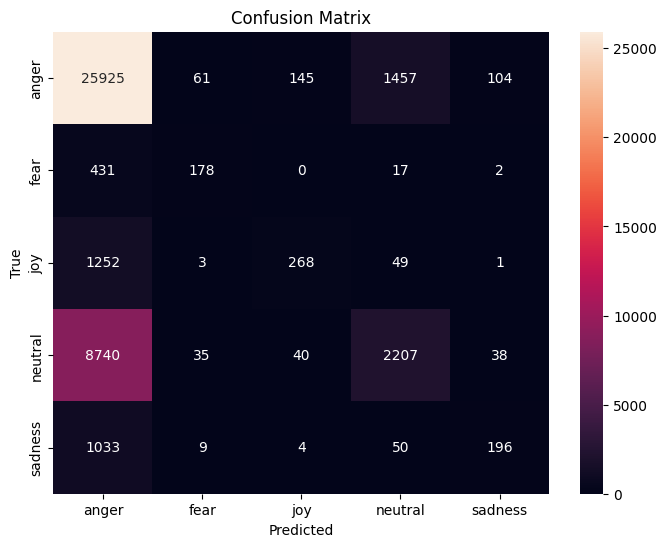

              precision    recall  f1-score   support

       anger       0.69      0.94      0.80     27692
        fear       0.62      0.28      0.39       628
         joy       0.59      0.17      0.26      1573
     neutral       0.58      0.20      0.30     11060
     sadness       0.57      0.15      0.24      1292

    accuracy                           0.68     42245
   macro avg       0.61      0.35      0.40     42245
weighted avg       0.66      0.68      0.62     42245



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = best_model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


In [ ]:
news_articles = [
    """Gunmen opened fire on tourists in Pahalgam, killing several civilians.
    The attack sparked outrage across the country and raised security concerns
    as authorities launched a large-scale search operation.""",

    """Indian armed forces conducted precision strikes targeting terrorist
    infrastructure across the border, officials said. The government stated
    the operation was carefully planned and successfully executed.""",

    """Following the strikes, tensions escalated as Pakistan accused India
    of provocation and warned of consequences, raising fears of further conflict."""
]


In [ ]:
news_seq = tokenizer.texts_to_sequences(news_articles)

news_pad = pad_sequences(
    news_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)


In [ ]:
pred_probs = best_model.predict(news_pad)
pred_labels = np.argmax(pred_probs, axis=1)

pred_emotions = label_encoder.inverse_transform(pred_labels)
pred_emotions


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array(['anger', 'anger', 'anger'], dtype=object)

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Article": [f"Article {i+1}" for i in range(len(news_articles))],
    "Predicted Emotion": pred_emotions
})

results_df


,Article,Predicted Emotion
0,Article 1,anger
1,Article 2,anger
2,Article 3,anger


from matplotlib import pyplot as plt
import seaborn as sns
results_df.groupby('Article').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Article": [f"Article {i+1}" for i in range(len(news_articles))],
    "Predicted Emotion": pred_emotions
})

results_df


,Article,Predicted Emotion
0,Article 1,anger
1,Article 2,anger
2,Article 3,anger


In [ ]:
for i, probs in enumerate(pred_probs):
    print(f"Article {i+1}:")
    for emotion, p in zip(label_encoder.classes_, probs):
        print(f"  {emotion}: {p:.2f}")
    print()


Article 1:
  anger: 0.65
  fear: 0.07
  joy: 0.02
  neutral: 0.23
  sadness: 0.03

Article 2:
  anger: 0.91
  fear: 0.00
  joy: 0.00
  neutral: 0.07
  sadness: 0.02

Article 3:
  anger: 0.81
  fear: 0.03
  joy: 0.00
  neutral: 0.15
  sadness: 0.01



In [ ]:
prob_df = pd.DataFrame(
    pred_probs,
    columns=label_encoder.classes_
)

prob_df["Article"] = [f"Article {i+1}" for i in range(len(news_articles))]
prob_df


,anger,fear,joy,neutral,sadness,Article
0,0.650186,0.074448,0.021438,0.225928,0.028000,Article 1
1,0.910589,0.000888,0.000744,0.068868,0.018912,Article 2
2,0.805691,0.028123,0.003656,0.147983,0.014547,Article 3


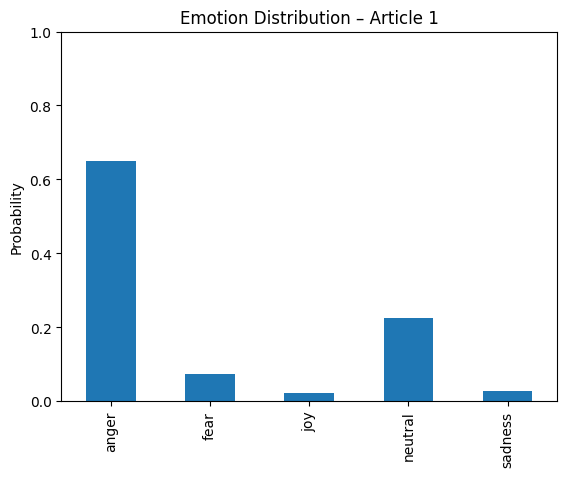

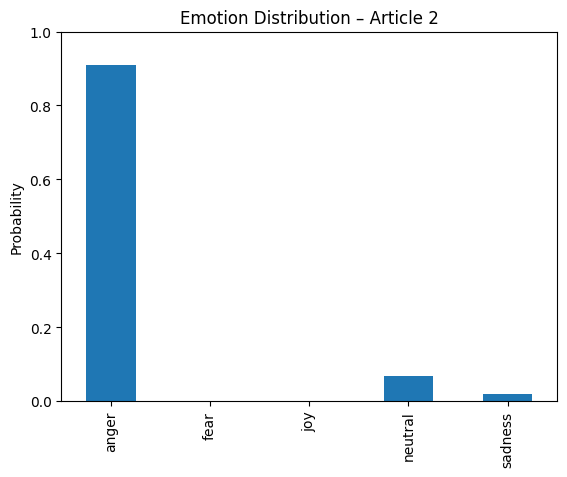

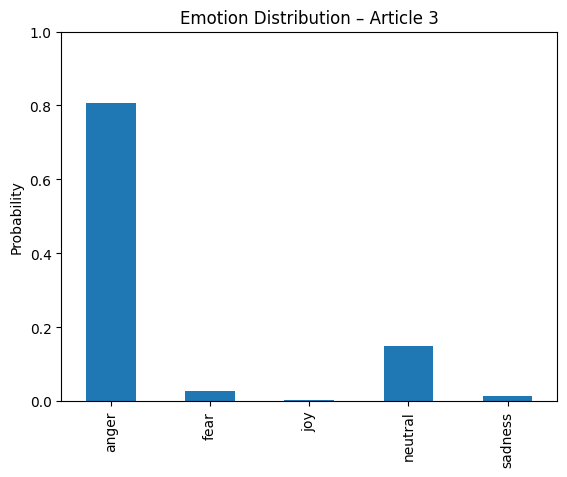

In [ ]:
for i in range(len(prob_df)):
    prob_df.loc[i, label_encoder.classes_].plot(
        kind="bar",
        title=f"Emotion Distribution – Article {i+1}",
        ylim=(0,1)
    )
    plt.ylabel("Probability")
    plt.show()


In [ ]:
import nltk
nltk.download("punkt")

from nltk.tokenize import sent_tokenize


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
sample_article = news_articles[0]

sentences = sent_tokenize(sample_article)

for i, s in enumerate(sentences, 1):
    print(f"Sentence {i}: {s}")


Sentence 1: Gunmen opened fire on tourists in Pahalgam, killing several civilians.
Sentence 2: The attack sparked outrage across the country and raised security concerns
    as authorities launched a large-scale search operation.


In [ ]:
def predict_sentence_emotions(sentences):
    seq = tokenizer.texts_to_sequences(sentences)
    pad = pad_sequences(
        seq,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    probs = best_model.predict(pad)
    return probs


In [ ]:
sentences = sent_tokenize(news_articles[0])
sentence_probs = predict_sentence_emotions(sentences)

sentence_df = pd.DataFrame(
    sentence_probs,
    columns=label_encoder.classes_
)

sentence_df["sentence"] = sentences
sentence_df


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step


,anger,fear,joy,neutral,sadness,sentence
0,0.417640,0.061243,0.018743,0.469960,0.032414,"Gunmen opened fire on tourists in Pahalgam, ki..."
1,0.702461,0.004992,0.003418,0.277284,0.011845,The attack sparked outrage across the country ...


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['anger'].plot(kind='hist', bins=20, title='anger')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['fear'].plot(kind='hist', bins=20, title='fear')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['sentence'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='anger', y='sentence', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['sentence'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='fear', y='sentence', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_20['sentence'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_20, x='joy', y='sentence', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
article_emotion_distribution = sentence_df[label_encoder.classes_].mean()

article_emotion_distribution


,0
anger,0.560051
fear,0.033117
joy,0.011081
neutral,0.373622
sadness,0.022129


In [ ]:
import matplotlib.pyplot as plt


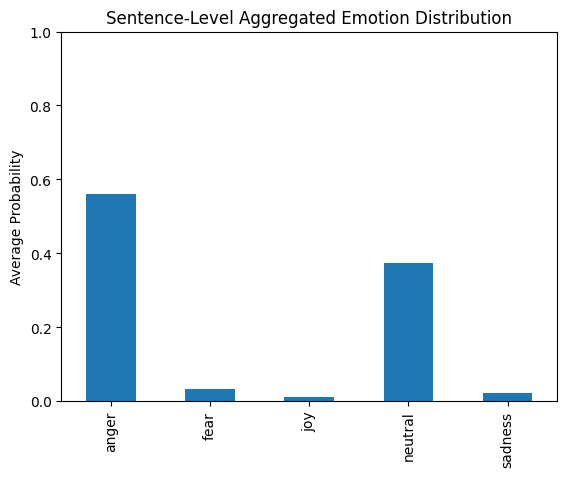

In [ ]:
article_emotion_distribution.plot(
    kind="bar",
    title="Sentence-Level Aggregated Emotion Distribution",
    ylim=(0,1)
)

plt.ylabel("Average Probability")
plt.show()


In [ ]:
before_attack = [
    """Gunmen opened fire on tourists in Pahalgam, killing several civilians.
    Security forces launched a manhunt as the nation mourned the victims."""
]

during_strikes = [
    """Indian armed forces conducted precision strikes targeting terrorist
    infrastructure across the border. Officials said the operation was
    carefully planned and successfully executed."""
]

after_response = [
    """Following the strikes, Pakistan accused India of provocation and warned
    of consequences, raising fears of further escalation in the region."""
]


In [ ]:
from nltk.tokenize import sent_tokenize

def article_emotion_distribution(article_text):
    sentences = sent_tokenize(article_text)
    probs = predict_sentence_emotions(sentences)

    df = pd.DataFrame(probs, columns=label_encoder.classes_)
    return df.mean()


In [ ]:
before_dist = pd.concat(
    [article_emotion_distribution(a) for a in before_attack],
    axis=1
).mean(axis=1)

during_dist = pd.concat(
    [article_emotion_distribution(a) for a in during_strikes],
    axis=1
).mean(axis=1)

after_dist = pd.concat(
    [article_emotion_distribution(a) for a in after_response],
    axis=1
).mean(axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step


In [ ]:
phase_df = pd.DataFrame({
    "Before Attack": before_dist,
    "During Strikes": during_dist,
    "After Response": after_dist
})

phase_df


,Before Attack,During Strikes,After Response
anger,0.511475,0.766922,0.773809
fear,0.031486,0.003695,0.013949
joy,0.010388,0.005574,0.003356
neutral,0.427752,0.207919,0.196060
sadness,0.018899,0.015889,0.012826


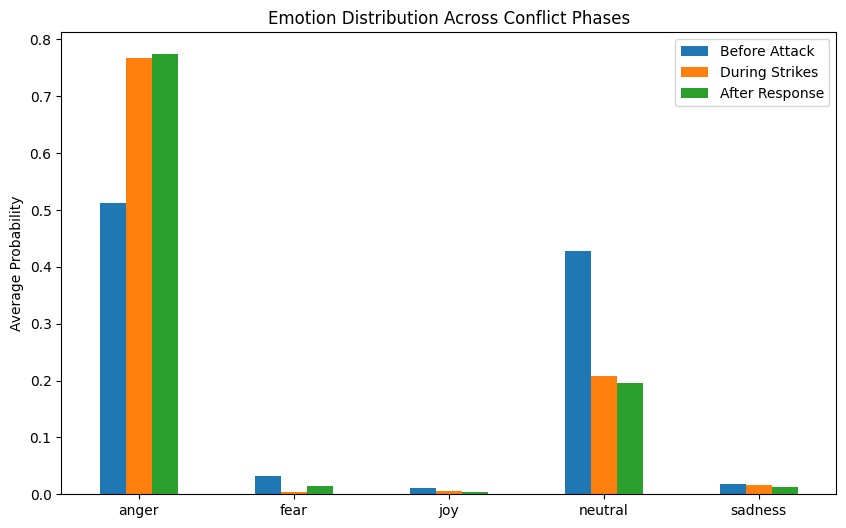

In [ ]:
phase_df.plot(
    kind="bar",
    figsize=(10,6),
    title="Emotion Distribution Across Conflict Phases"
)

plt.ylabel("Average Probability")
plt.xticks(rotation=0)
plt.show()



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
def simple_sent_tokenize(text):
    sentences = re.split(r'(?<=[.!?])\s+', str(text).strip())
    return [s for s in sentences if len(s.strip()) > 0]


In [ ]:
df = pd.read_csv("Pahalgam_Media_Articles_CLEANED.csv")

df["phase"] = (
    df["phase"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"beofre": "before"})
)

df = df[df["phase"].isin(["before", "during", "after"])]

df["phase"].value_counts()


,count
phase,
before,8
after,8
during,7


In [ ]:
def article_emotion_distribution(article_text):
    sentences = simple_sent_tokenize(article_text)

    seq = tokenizer.texts_to_sequences(sentences)
    pad = pad_sequences(
        seq,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    probs = best_model.predict(pad, verbose=0)
    return pd.DataFrame(probs, columns=label_encoder.classes_).mean()


In [ ]:
emotion_rows = []

for _, row in df.iterrows():
    dist = article_emotion_distribution(row["body_text"])
    dist["phase"] = row["phase"]
    emotion_rows.append(dist)

emotion_df = pd.DataFrame(emotion_rows)
emotion_df.head()


,anger,fear,joy,neutral,sadness,phase
0,0.210616,0.209488,0.195787,0.190605,0.193503,before
1,0.209346,0.209356,0.196269,0.191869,0.193160,before
2,0.207484,0.211589,0.196788,0.191753,0.192386,before
3,0.206995,0.208886,0.196800,0.192887,0.194431,before
4,0.210004,0.208716,0.196092,0.192072,0.193116,before


In [ ]:
phase_summary = emotion_df.groupby("phase").mean()
phase_summary


,anger,fear,joy,neutral,sadness
phase,,,,,
after,0.210137,0.209039,0.195955,0.191685,0.193184
before,0.209301,0.209365,0.196329,0.191803,0.193203
during,0.210808,0.208798,0.195521,0.191769,0.193104


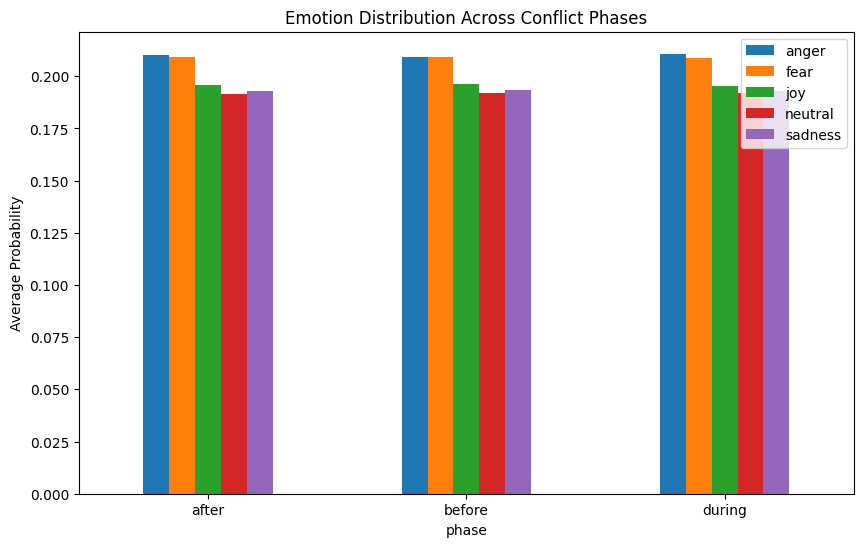

In [ ]:
phase_summary.plot(
    kind="bar",
    figsize=(10,6),
    title="Emotion Distribution Across Conflict Phases"
)

plt.ylabel("Average Probability")
plt.xticks(rotation=0)
plt.show()


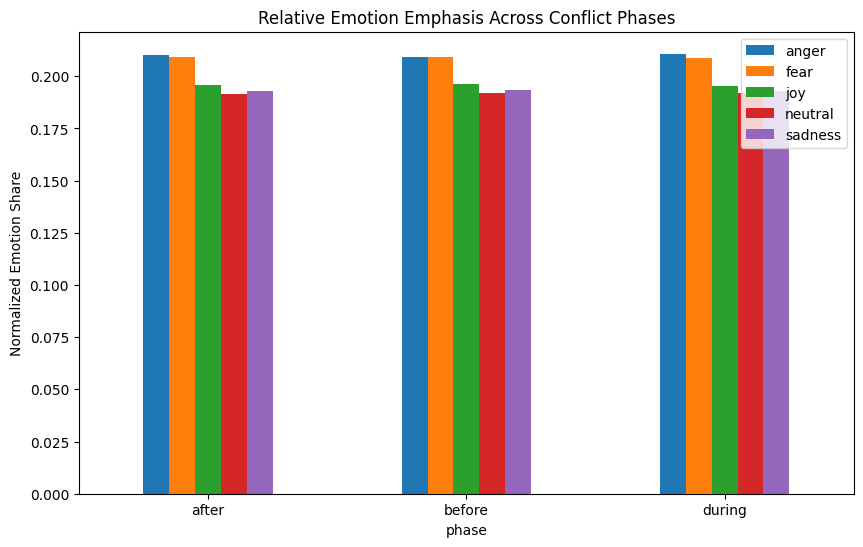

In [ ]:
phase_norm = phase_summary.div(phase_summary.sum(axis=1), axis=0)

phase_norm.plot(
    kind="bar",
    figsize=(10,6),
    title="Relative Emotion Emphasis Across Conflict Phases"
)

plt.ylabel("Normalized Emotion Share")
plt.xticks(rotation=0)
plt.show()
